<div style="font-family:Arial; background-color:#f6f7f9; padding:30px; border-radius:10px;">

<h1 style="color:#1f4e79; text-align:center; margin-bottom:5px;">
Modélisation Générative du Risque Climatique
</h1>

<h3 style="color:#2563eb; text-align:center; margin-top:0;">
Application à l’Indice de Haines — Potentiel de Feux Extrêmes
</h3>

<hr style="border:1px solid #dbe2ef; margin:25px 0;">

<h2 style="color:#1f4e79;">1. Introduction</h2>

<h3 style="color:#2e75b6;">1.1 Contexte physique et climatique</h3>

<p>
L’intensification des incendies de forêt constitue l’une des manifestations les plus critiques du changement climatique.
Au-delà de leur fréquence, c’est leur <b>caractère extrême et imprévisible</b> qui pose aujourd’hui un défi majeur aux modèles de risque.
Ces événements, souvent qualifiés de <i>méga-feux</i>, échappent aux dynamiques classiques en développant leurs propres mécanismes atmosphériques.
</p>

<p>
Dans ce contexte, l’<b>Indice de Haines</b> s’impose comme un indicateur clé.
Il ne se limite pas aux conditions de surface, mais capture les propriétés de la basse atmosphère (≈ 1500m – 3000m), essentielles à la propagation verticale des feux.
</p>

<ul>
<li><b>Stabilité atmosphérique :</b> capacité de l’air à favoriser l’ascension des masses chaudes</li>
<li><b>Sécheresse en altitude :</b> déficit d’humidité facilitant l’embrasement</li>
</ul>

<p style="font-family:monospace; font-size:15px; color:#333;">
H = (T850 − T700) + (T850 − DP850)
</p>

<p>
Cet indice permet ainsi d’identifier des configurations propices à des dynamiques de feu auto-entretenues.
</p>

<hr style="border:1px solid #dbe2ef; margin:25px 0;">

<h3 style="color:#2e75b6;">1.2 Enjeux pour l’assurance</h3>

<p>
Pour les assureurs, la compréhension fine de ces dynamiques est essentielle.
Les pertes associées aux événements extrêmes sont caractérisées par une forte concentration et une faible fréquence.
</p>

<ul>
<li>Anticipation des événements de forte sévérité</li>
<li>Amélioration de la sélection des risques</li>
<li>Dimensionnement des réserves et du capital économique</li>
</ul>

<p>
L’Indice de Haines constitue ainsi un outil complémentaire aux modèles traditionnels, notamment pour l’analyse des scénarios extrêmes.
</p>

<hr style="border:1px solid #dbe2ef; margin:25px 0;">

<h2 style="color:#1f4e79;">2. Problématique</h2>

<h3 style="color:#2e75b6;">2.1 Limites des données historiques</h3>

<p>
Les bases de données climatiques modernes, telles que ERA5, offrent une couverture riche mais limitée dans le temps.
Cet horizon temporel reste insuffisant pour capturer des événements rares, mais pourtant plausibles physiquement.
</p>

<p>
Les approches statistiques classiques tendent à sous-estimer les <b>queues de distribution</b>, conduisant à une mauvaise évaluation du risque extrême.
</p>

<hr style="border:1px solid #dbe2ef; margin:25px 0;">

<h3 style="color:#2e75b6;">2.2 Question de recherche</h3>

<p style="font-style:italic; color:#1f4e79;">
Dans quelle mesure les modèles d’IA générative (VAE, GAN) permettent-ils de simuler des scénarios climatiques extrêmes, réalistes et cohérents, afin d’améliorer la modélisation du risque et la tarification en assurance ?
</p>

<p>
L’objectif est de dépasser les limites de l’historique observé en générant des données synthétiques capables de :
</p>

<ul>
<li>reproduire la structure statistique réelle</li>
<li>capturer les événements extrêmes</li>
<li>enrichir les analyses de stress et de solvabilité</li>
</ul>

</div>

<div style="font-family:Arial; line-height:1.5;">
Nous procédons au chargement des données ERA5 afin de construire l’indice de Haines à partir des variables atmosphériques.
Les températures aux niveaux 850 hPa et 700 hPa ainsi que l’humidité relative sont extraites.
Une approximation de la dépression du point de rosée est ensuite calculée, permettant de dériver l’indice final.
Une vérification des dimensions et des premières valeurs est réalisée afin de valider la cohérence des données.
</div>

In [42]:
# Installation complète des dépendances nécessaires au projet

!pip install --upgrade pip

# Données climatiques et manipulation
!pip install cdsapi xarray netcdf4 pandas numpy

# Visualisation
!pip install matplotlib seaborn

# Machine Learning / Deep Learning
!pip install torch torchvision torchaudio

# Statistiques
!pip install scipy scikit-learn

# Optionnel (utile pour notebooks propres)
!pip install tqdm

  Using cached pip-26.0.1-py3-none-any.whl.metadata (4.7 kB)
Using cached pip-26.0.1-py3-none-any.whl (1.8 MB)



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: To modify pip, please run the following command:
c:\Users\damso\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


  Using cached cdsapi-0.7.7-py2.py3-none-any.whl.metadata (3.1 kB)
  Using cached ecmwf_datastores_client-0.5.1-py3-none-any.whl.metadata (21 kB)
  Using cached multiurl-0.3.7-py3-none-any.whl.metadata (2.8 kB)
Using cached cdsapi-0.7.7-py2.py3-none-any.whl (12 kB)
Using cached ecmwf_datastores_client-0.5.1-py3-none-any.whl (29 kB)
Using cached multiurl-0.3.7-py3-none-any.whl (21 kB)

   ---------------------------------------- 0/3 [multiurl]
   ---------------------------------------- 0/3 [multiurl]
   ---------------------------------------- 0/3 [multiurl]
   ---------------------------------------- 0/3 [multiurl]
   ---------------------------------------- 0/3 [multiurl]
   ---------------------------------------- 0/3 [multiurl]
   ---------------------------------------- 0/3 [multiurl]
   ---------------------------------------- 0/3 [multiurl]
   ---------------------------------------- 0/3 [multiurl]
   ------------- -------------------------- 1/3 [ecmwf-datastores-client]
   ----


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/4.3 MB ? eta -:--:--
   ------------------- -------------------- 2.1/4.3 MB 12.1 MB/s eta 0:00:01
   -------------------------------------- - 4.2/4.3 MB 11.3 MB/s eta 0:00:01
   -------------------------------------- - 4.2/4.3 MB 11.3 MB/s eta 0:00:01
   -------------------------------------- - 4.2/4.3 MB 11.3 MB/s eta 0:00:01
   ---------------------------------------- 4.3/4.3 MB 4.5 MB/s  0:00:00

   ---------------------------------------- 0/2 [torchaudio]
   ---------------------------------------- 0/2 [torchaudio]
   ---------------------------------------- 0/2 [torchaudio]
   ---------------------------------------- 0/2 [torchaudio]
   ---------------------------------------- 0/2 [torchaudio]
   ---------------------------------------- 0/2 [torchaudio]
   ---------------------------------------- 0/2 [torchaudio]
   ---------------------------------------- 0/2 [torchaudio]
   ---------------------------------------- 0/2 [torchaudio]



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [43]:
import xarray as xr
import numpy as np

# 1. Chargement du fichier NetCDF contenant les données ERA5
ds = xr.open_dataset('haines_data.nc')

# 2. Extraction des variables nécessaires
# Température à 850 hPa (convertie de Kelvin à Celsius)
t850 = ds.t.sel(pressure_level=850) - 273.15

# Température à 700 hPa (convertie de Kelvin à Celsius)
t700 = ds.t.sel(pressure_level=700) - 273.15

# Humidité relative à 850 hPa
rh850 = ds.r.sel(pressure_level=850)  # 'r' correspond à relative humidity

# 3. Calcul de la dépression du point de rosée (approximation simple)
# Plus l'humidité est faible, plus la dépression est élevée (air sec)
dewpoint_depression_850 = (100 - rh850) / 5

# 4. Calcul de l'indice de Haines
# Combinaison de :
# - l'instabilité thermique (t850 - t700)
# - la sécheresse de l'air (dewpoint_depression)
haines_index = (t850 - t700) + dewpoint_depression_850

# 5. Vérification des résultats
# Affiche les dimensions (latitude, longitude, temps, etc.)
print("Dimensions de l'indice :", haines_index.dims)

# Affiche un aperçu des premières valeurs
print("Aperçu des valeurs :", haines_index.values.flatten()[:5])

Dimensions de l'indice : ('valid_time', 'latitude', 'longitude')
Aperçu des valeurs : [16.769245 13.93526  10.052057  7.256354  6.234088]


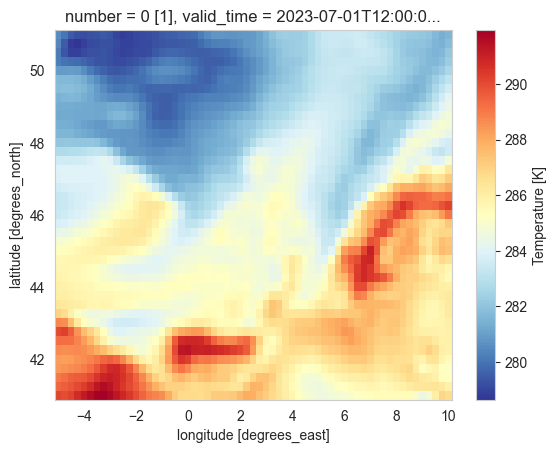

In [44]:
# On remplace 'time' par 'valid_time'
ds.t.sel(pressure_level=850, valid_time='2023-07-01T12:00:00').plot(cmap='RdYlBu_r')

<div style="font-family:Arial; line-height:1.5;">
<b>Objectif :</b> transformer l’indice de Haines (xarray) en DataFrame pour l’analyse.
On convertit les données en format tabulaire, on supprime les valeurs manquantes, puis on ajoute une catégorisation du risque.
Cette étape permet de préparer les données pour des analyses statistiques ou des modèles de machine learning.
</div>

In [45]:
# Conversion du cube xarray en DataFrame Pandas
# On transforme la structure multidimensionnelle (lat, lon, temps) en tableau classique
df = haines_index.to_dataframe(name='haines_index').reset_index()

# Nettoyage : suppression des valeurs manquantes (NaN)
# Important pour éviter des erreurs dans les modèles ou statistiques
df = df.dropna()

# Ajout d'une variable catégorielle de risque
# Permet de simplifier l'interprétation (notamment en assurance)
def categorize_haines(val):
    if val < 7:
        return 'Low'        # faible risque
    if val < 9:
        return 'Moderate'   # risque modéré
    return 'High'           # risque élevé

# Application de la fonction à chaque observation
df['risk_level'] = df['haines_index'].apply(categorize_haines)

# Vérification du résultat
print(df.head())

           valid_time  latitude  longitude  number expver  pressure_level  \
0 2023-07-01 12:00:00      51.0      -5.00       0   0001           850.0   
1 2023-07-01 12:00:00      51.0      -4.75       0   0001           850.0   
2 2023-07-01 12:00:00      51.0      -4.50       0   0001           850.0   
3 2023-07-01 12:00:00      51.0      -4.25       0   0001           850.0   
4 2023-07-01 12:00:00      51.0      -4.00       0   0001           850.0   

   haines_index risk_level  
0     16.769245       High  
1     13.935260       High  
2     10.052057       High  
3      7.256354   Moderate  
4      6.234088        Low  


In [46]:
# Vérification globale
print("--- Diagnostic des données ---")
print(df.info())

# Calcul des manquants
missing = df.isnull().sum()
print("\n--- Valeurs manquantes ---")
print(missing)

--- Diagnostic des données ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77531 entries, 0 to 77530
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   valid_time      77531 non-null  datetime64[ns]
 1   latitude        77531 non-null  float64       
 2   longitude       77531 non-null  float64       
 3   number          77531 non-null  int64         
 4   expver          77531 non-null  object        
 5   pressure_level  77531 non-null  float64       
 6   haines_index    77531 non-null  float32       
 7   risk_level      77531 non-null  object        
dtypes: datetime64[ns](1), float32(1), float64(3), int64(1), object(2)
memory usage: 4.4+ MB
None

--- Valeurs manquantes ---
valid_time        0
latitude          0
longitude         0
number            0
expver            0
pressure_level    0
haines_index      0
risk_level        0
dtype: int64


<div style="font-family:Arial; line-height:1.5;">
Nous calculons les statistiques descriptives de l’indice (moyenne, dispersion) ainsi que les indicateurs de forme de la distribution (asymétrie et aplatissement).
La répartition des niveaux de risque est ensuite analysée afin d’obtenir une lecture directe de l’exposition et de la fréquence des situations critiques.
</div>

In [47]:
from scipy.stats import skew, kurtosis

# Statistiques descriptives de base (moyenne, std, min, max, etc.)
stats_cont = df['haines_index'].describe()

# Calcul de l'asymétrie (skewness)
# Mesure si la distribution est étirée vers la droite (positive) ou gauche (négative)
skew_val = skew(df['haines_index'].dropna())

# Calcul de la kurtosis (aplatissement)
# Mesure la présence d'extrêmes (queues épaisses ou non)
kurt_val = kurtosis(df['haines_index'].dropna())

# Affichage des résultats principaux
print(f"Moyenne : {stats_cont['mean']:.2f}")
print(f"Écart-type : {stats_cont['std']:.2f}")
print(f"Skewness (Asymétrie) : {skew_val:.2f}")
print(f"Kurtosis (Aplatissement) : {kurt_val:.2f}")

# Fréquence des catégories de risque (en %)
# Permet d'interpréter directement la distribution en termes de risque
risk_counts = df['risk_level'].value_counts(normalize=True) * 100

print("\n--- Répartition du Risque (%) ---")
print(risk_counts)

Moyenne : 15.17
Écart-type : 6.42
Skewness (Asymétrie) : 0.39
Kurtosis (Aplatissement) : -0.44

--- Répartition du Risque (%) ---
risk_level
High        82.534728
Moderate     8.991242
Low          8.474030
Name: proportion, dtype: float64


<div style="font-family:Arial; line-height:1.5;">
Nous procédons ensuite à une analyse visuelle de la distribution de l’indice de Haines.
Un histogramme avec densité permet d’observer la forme globale de la distribution, tandis qu’un boxplot met en évidence la présence d’extrêmes.
La répartition des niveaux de risque est représentée afin de faciliter l’interprétation catégorielle.
Enfin, une relation entre latitude et indice est explorée afin d’identifier un éventuel gradient spatial.
</div>

C:\Users\damso\AppData\Local\Temp\ipykernel_10484\3716835263.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not f

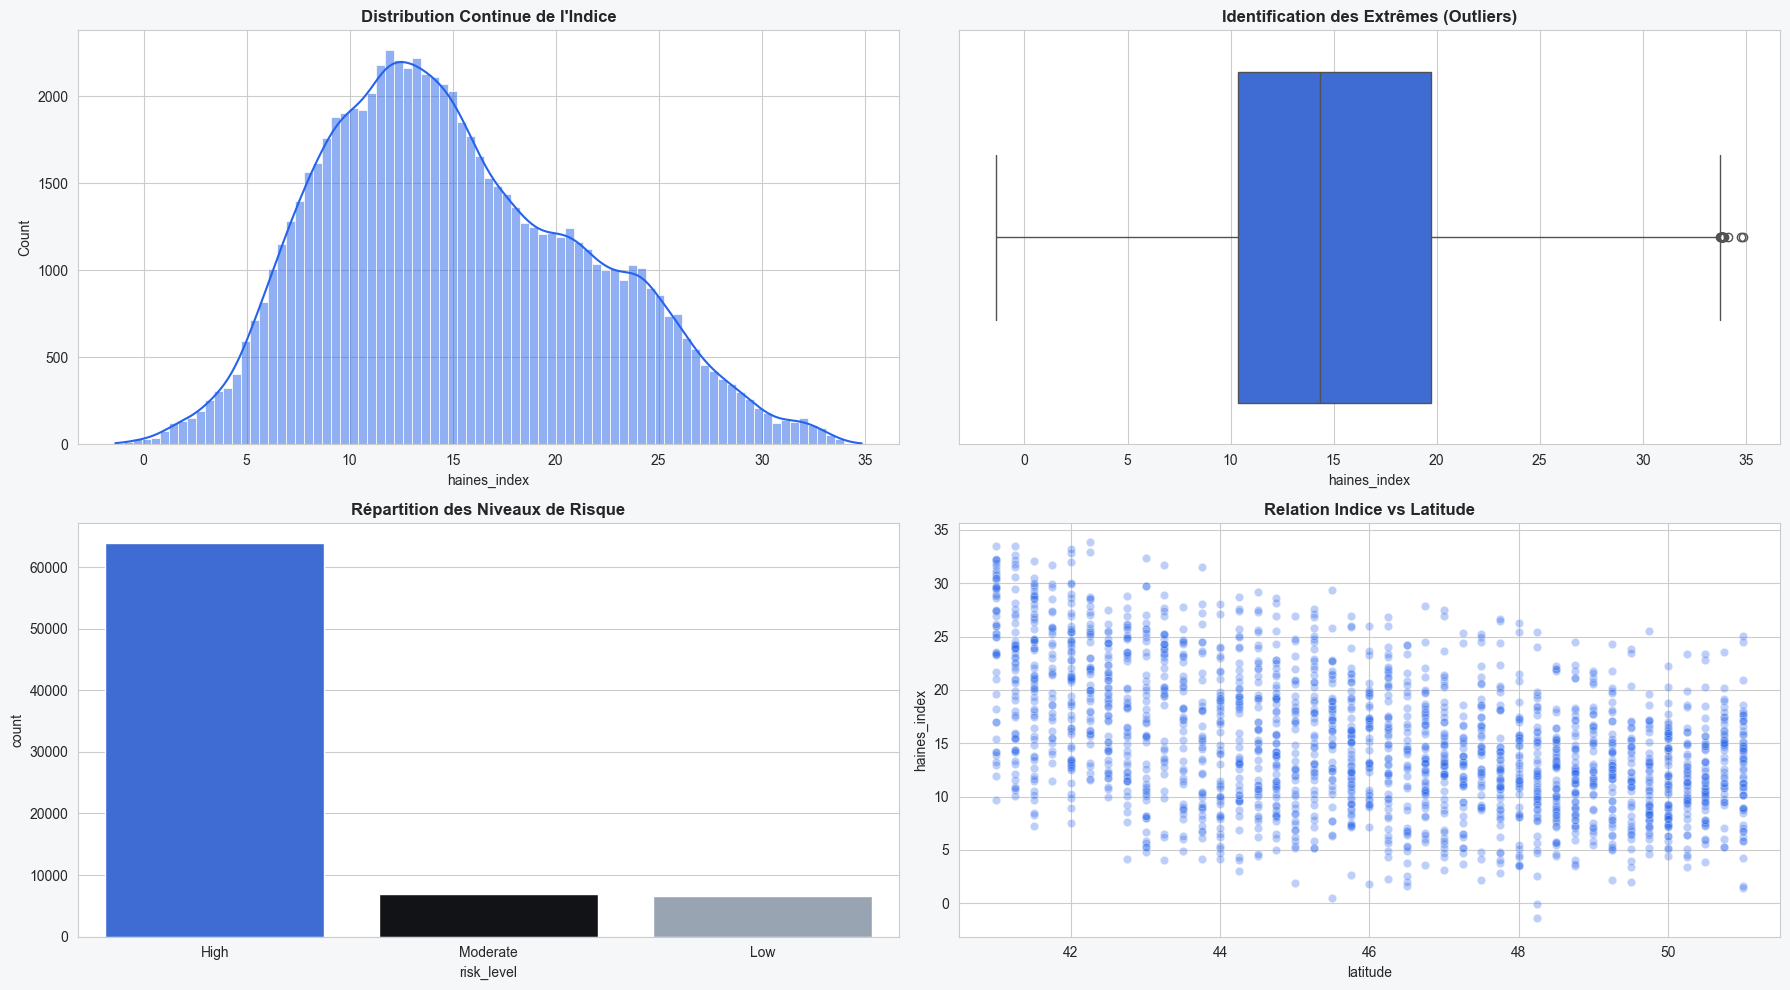

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration du style graphique (police et couleurs)
plt.rcParams['font.family'] = ['Inter', 'sans-serif']
MAIN_COLOR = '#2563eb'
BG_COLOR = '#f6f7f9'

# Création de la figure principale
fig = plt.figure(figsize=(18, 10), facecolor=BG_COLOR)

# 1. Distribution continue : histogramme + estimation de densité (KDE)
ax1 = plt.subplot(2, 2, 1)
sns.histplot(df['haines_index'], kde=True, color=MAIN_COLOR, ax=ax1)
ax1.set_title('Distribution Continue de l\'Indice', fontweight='bold')

# 2. Boxplot : identification des valeurs extrêmes (outliers)
ax2 = plt.subplot(2, 2, 2)
sns.boxplot(x=df['haines_index'], color=MAIN_COLOR, ax=ax2)
ax2.set_title('Identification des Extrêmes (Outliers)', fontweight='bold')

# 3. Distribution catégorielle : répartition des niveaux de risque
ax3 = plt.subplot(2, 2, 3)
sns.countplot(
    data=df,
    x='risk_level',
    palette=[MAIN_COLOR, '#111317', '#94a3b8'],
    ax=ax3
)
ax3.set_title('Répartition des Niveaux de Risque', fontweight='bold')

# 4. Relation spatiale : latitude vs indice de Haines
# Un échantillon est utilisé pour améliorer la lisibilité
ax4 = plt.subplot(2, 2, 4)
sns.scatterplot(
    data=df.sample(min(2000, len(df))),
    x='latitude',
    y='haines_index',
    alpha=0.3,
    color=MAIN_COLOR,
    ax=ax4
)
ax4.set_title('Relation Indice vs Latitude', fontweight='bold')

# Ajustement automatique des espacements
plt.tight_layout()

# Affichage final
plt.show()

<div style="font-family:Arial; line-height:1.5;">
Nous structurons l’analyse en trois étapes : visualisation de la distribution, transformation des données et étude statistique approfondie.
La transformation de Box-Cox permet de corriger l’asymétrie, puis une normalisation est appliquée pour préparer les données aux modèles.
Enfin, des indicateurs statistiques et un test de normalité permettent de caractériser précisément la distribution.
</div>

findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font f

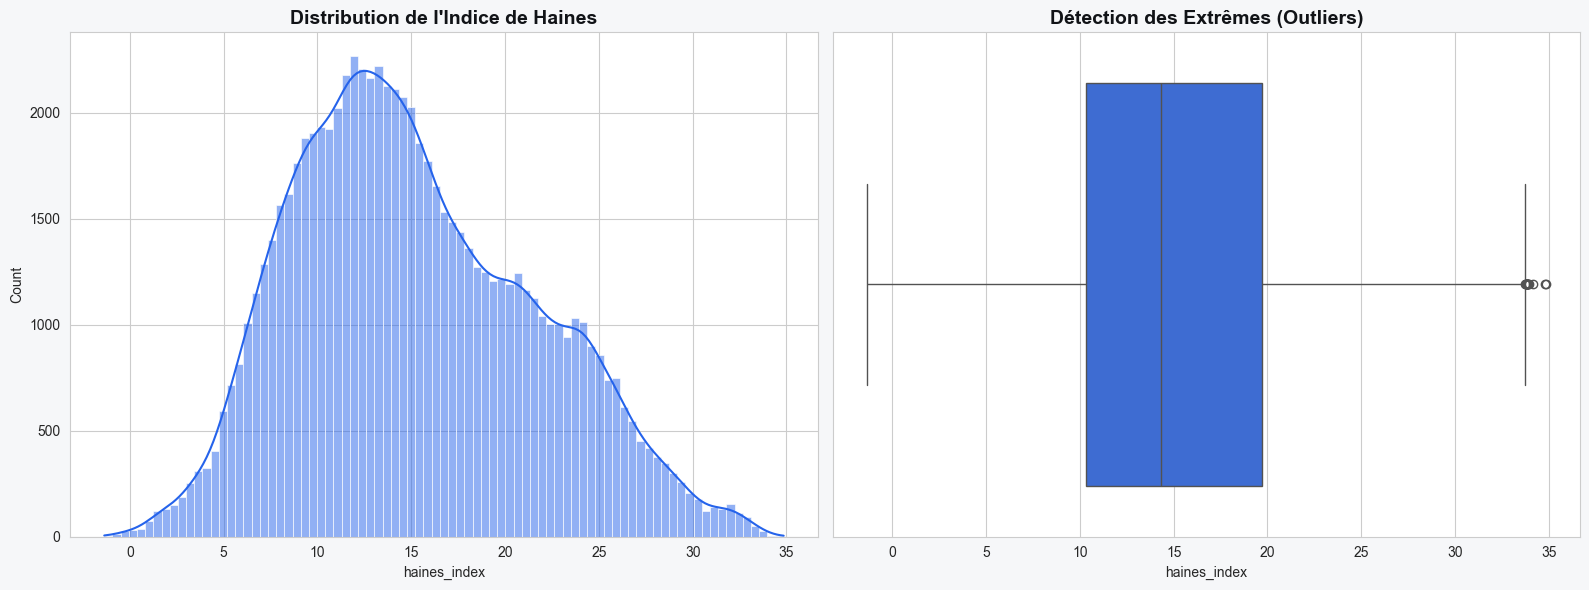

Lambda de Box-Cox : 0.53
Structure Statistique de l'Indice :
- Skewness (Asymétrie) : 0.388
- Kurtosis (Aplatissement) : -0.443
- Test de Shapiro-Wilk (p-value) : 0.00000


In [49]:
# =========================================================
# IMPORTS
# =========================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler

# =========================================================
# CONFIGURATION GRAPHIQUE
# =========================================================
MAIN_BLUE = '#2563eb'
DARK_GREY = '#111317'
LIGHT_BG = '#f6f7f9'

plt.rcParams['font.family'] = ['Inter', 'sans-serif']


# =========================================================
# 1. VISUALISATION DE LA DISTRIBUTION
# =========================================================

# Création d'une figure avec deux sous-graphiques
fig, ax = plt.subplots(1, 2, figsize=(16, 6), facecolor=LIGHT_BG)

# Histogramme + densité
sns.histplot(df['haines_index'], kde=True, color=MAIN_BLUE, ax=ax[0])
ax[0].set_title('Distribution de l\'Indice de Haines', fontsize=14, fontweight='bold', color=DARK_GREY)
ax[0].set_facecolor('white')

# Boxplot pour détecter les extrêmes
sns.boxplot(x=df['haines_index'], color=MAIN_BLUE, ax=ax[1])
ax[1].set_title('Détection des Extrêmes (Outliers)', fontsize=14, fontweight='bold', color=DARK_GREY)
ax[1].set_facecolor('white')

plt.tight_layout()
plt.show()


# =========================================================
# 2. TRANSFORMATION DES DONNÉES (BOX-COX)
# =========================================================

# Box-Cox nécessite des données strictement positives
data_for_transform = df['haines_index'] + abs(df['haines_index'].min()) + 1

# Application de la transformation
df['haines_transformed'], lmbda = stats.boxcox(data_for_transform)

print(f"Lambda de Box-Cox : {lmbda:.2f}")


# =========================================================
# 3. NORMALISATION
# =========================================================

scaler = MinMaxScaler()
df['haines_final'] = scaler.fit_transform(df[['haines_transformed']])


# =========================================================
# 4. ANALYSE STATISTIQUE
# =========================================================

data = df['haines_index'].dropna()

# Moments d'ordre supérieur
skewness = stats.skew(data)
kurt = stats.kurtosis(data)

print("Structure Statistique de l'Indice :")
print(f"- Skewness (Asymétrie) : {skewness:.3f}")
print(f"- Kurtosis (Aplatissement) : {kurt:.3f}")

# Test de normalité de Shapiro-Wilk
shapiro_test = stats.shapiro(data.sample(min(len(data), 5000)))

print(f"- Test de Shapiro-Wilk (p-value) : {shapiro_test.pvalue:.5f}")

# VAE

<div style="font-family:Arial; line-height:1.5;">
Nous mettons en place un Variational Autoencoder (VAE) afin d’apprendre une représentation latente de l’indice de Haines.
Le modèle encode les données dans un espace probabiliste puis les reconstruit, ce qui permet de générer de nouveaux scénarios.
L’entraînement repose sur un compromis entre qualité de reconstruction et régularisation de l’espace latent.
Enfin, des données synthétiques sont générées puis ramenées dans l’échelle initiale via inversion des transformations.
</div>

train_loader est prêt avec 77531 échantillons.
Epoch 10/100 - Loss: 0.023831
Epoch 20/100 - Loss: 0.023825
Epoch 30/100 - Loss: 0.023823
Epoch 40/100 - Loss: 0.023823
Epoch 50/100 - Loss: 0.023817
Epoch 60/100 - Loss: 0.023814
Epoch 70/100 - Loss: 0.023818
Epoch 80/100 - Loss: 0.023814
Epoch 90/100 - Loss: 0.023813


findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.


Epoch 100/100 - Loss: 0.023814


findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font f

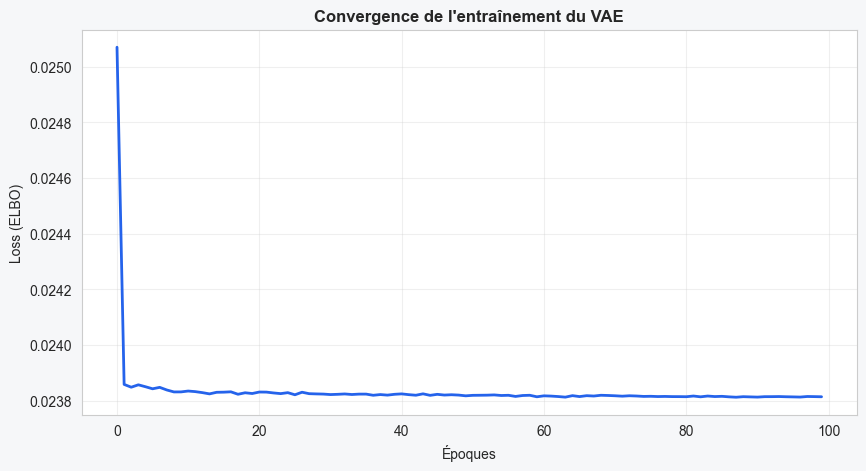

Génération terminée. Max synthétique : 14.63 (vs Max réel : 34.85)


In [50]:
# =========================================================
# IMPORTS
# =========================================================
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset
from scipy.special import inv_boxcox


# =========================================================
# 1. PRÉPARATION DES DONNÉES
# =========================================================

# Conversion en tenseur (optimisé : reshape direct)
X_train = torch.FloatTensor(df['haines_final'].values.reshape(-1, 1))

# DataLoader pour l'entraînement
train_loader = DataLoader(
    TensorDataset(X_train),
    batch_size=32,
    shuffle=True
)

print(f"train_loader est prêt avec {len(X_train)} échantillons.")


# =========================================================
# 2. DÉFINITION DU MODÈLE VAE
# =========================================================

class HainesVAE(nn.Module):
    def __init__(self, input_dim=1, latent_dim=2):
        super(HainesVAE, self).__init__()

        # Encodeur
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU()
        )

        # Paramètres de la distribution latente
        self.fc_mu = nn.Linear(8, latent_dim)
        self.fc_logvar = nn.Linear(8, latent_dim)

        # Décodeur
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim),
            nn.Sigmoid()  # garantit des sorties dans [0,1]
        )

    # Reparametrization trick
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar


# Initialisation
model = HainesVAE(latent_dim=2)
optimizer = optim.Adam(model.parameters(), lr=1e-3)


# =========================================================
# 3. FONCTION DE PERTE (ELBO)
# =========================================================

def loss_function(recon_x, x, mu, logvar):
    # Reconstruction : proximité entre données réelles et reconstruites
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction='sum')

    # Régularisation : contraint l'espace latent à suivre une loi normale
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return recon_loss + kld_loss


# =========================================================
# 4. ENTRAÎNEMENT
# =========================================================

epochs = 100
model.train()
losses = []

for epoch in range(epochs):
    train_loss = 0

    for (data,) in train_loader:
        optimizer.zero_grad()

        recon_batch, mu, logvar = model(data)

        loss = loss_function(recon_batch, data, mu, logvar)
        loss.backward()

        optimizer.step()
        train_loss += loss.item()

    avg_loss = train_loss / len(train_loader.dataset)
    losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.6f}')


# =========================================================
# 5. VISUALISATION DE LA CONVERGENCE
# =========================================================

plt.figure(figsize=(10, 5), facecolor='#f6f7f9')
plt.plot(losses, color='#2563eb', lw=2)
plt.title("Convergence de l'entraînement du VAE", fontweight='bold')
plt.xlabel("Époques")
plt.ylabel("Loss (ELBO)")
plt.grid(alpha=0.3)
plt.show()


# =========================================================
# 6. GÉNÉRATION DE DONNÉES SYNTHÉTIQUES
# =========================================================

# Paramètre utilisé lors du preprocessing
shift = abs(df['haines_index'].min()) + 1

model.eval()
with torch.no_grad():

    # Échantillonnage dans l'espace latent
    z = torch.randn(10000, 2)

    # Génération dans l'espace normalisé
    generated_scaled = model.decoder(z).numpy()

    # Inversion de la normalisation MinMax
    generated_transformed = scaler.inverse_transform(generated_scaled)

    # Inversion de la transformation Box-Cox
    haines_synth = inv_boxcox(generated_transformed, lmbda) - shift


# Vérification finale
print(f"Génération terminée. Max synthétique : {haines_synth.max():.2f} (vs Max réel : {df['haines_index'].max():.2f})")

## VAE 2

<div style="font-family:Arial; line-height:1.5;">
Nous enrichissons le VAE afin de mieux capturer les événements extrêmes.
L’architecture est approfondie pour améliorer la capacité de représentation, puis un entraînement classique est réalisé.
Une seconde étape introduit une pondération des observations élevées afin de renforcer l’apprentissage des queues de distribution.
Enfin, les données synthétiques sont générées et comparées à la réalité à l’aide de métriques de risque et de visualisations.
</div>

Lancement de l'entraînement du VAE Pro...
Époque 50/300 | Loss: 0.023819
Époque 100/300 | Loss: 0.023813
Époque 150/300 | Loss: 0.023812
Époque 200/300 | Loss: 0.023811
Époque 250/300 | Loss: 0.023811
Époque 300/300 | Loss: 0.023810
Entraînement terminé !

--- RÉSULTATS DU MODÈLE PRO ---
Max Réel (ERA5)      : 34.85
Max Synthétique (IA) : 14.61
Époque 100 | Loss: 0.505134
Époque 200 | Loss: 0.506331
Époque 300 | Loss: 0.505744
Époque 400 | Loss: 0.506248
Époque 500 | Loss: 0.503801
Entraînement 'Extrême' terminé !


findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font f

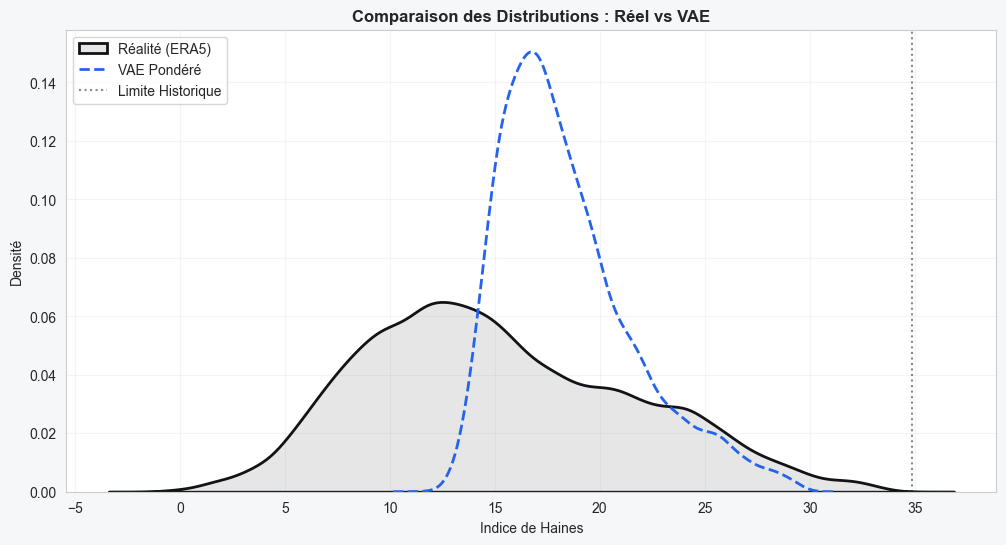

--- RÉSULTATS APRÈS ENTRAÎNEMENT PONDÉRÉ ---
Max Réel (ERA5)       : 34.85
Max Synthétique (VAE) : 29.63
Écart de sévérité     : 5.22
VaR 99% Réelle        : 30.70
VaR 99% IA            : 27.93


In [51]:
# =========================================================
# IMPORTS
# =========================================================
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.special import inv_boxcox


# =========================================================
# 1. MODÈLE VAE AMÉLIORÉ
# =========================================================

class HainesVAE_Pro(nn.Module):
    def __init__(self, input_dim=1, latent_dim=2):
        super(HainesVAE_Pro, self).__init__()

        # Encodeur plus profond
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(32, latent_dim)
        self.fc_logvar = nn.Linear(32, latent_dim)

        # Décodeur plus profond
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar


# =========================================================
# 2. ENTRAÎNEMENT STANDARD
# =========================================================

model = HainesVAE_Pro()
optimizer = optim.Adam(model.parameters(), lr=5e-4)

epochs = 300
model.train()
train_losses = []

print("Lancement de l'entraînement du VAE Pro...")

for epoch in range(epochs):
    overall_loss = 0

    for (x,) in train_loader:
        optimizer.zero_grad()

        recon_x, mu, logvar = model(x)

        # Loss ELBO classique
        recon_loss = nn.functional.mse_loss(recon_x, x, reduction='sum')
        kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

        loss = recon_loss + kld_loss
        loss.backward()

        optimizer.step()
        overall_loss += loss.item()

    avg_loss = overall_loss / len(train_loader.dataset)
    train_losses.append(avg_loss)

    if (epoch + 1) % 50 == 0:
        print(f"Époque {epoch+1}/{epochs} | Loss: {avg_loss:.6f}")

print("Entraînement terminé !")


# =========================================================
# 3. GÉNÉRATION STANDARD
# =========================================================

shift = abs(df['haines_index'].min()) + 1

model.eval()
with torch.no_grad():

    z = torch.randn(10000, 2)
    gen_scaled = model.decoder(z).numpy()

    # Inversion des transformations
    gen_transformed = scaler.inverse_transform(gen_scaled)
    haines_synth = inv_boxcox(gen_transformed, lmbda) - shift

print(f"\n--- RÉSULTATS DU MODÈLE PRO ---")
print(f"Max Réel (ERA5)      : {df['haines_index'].max():.2f}")
print(f"Max Synthétique (IA) : {haines_synth.max():.2f}")


# =========================================================
# 4. ENTRAÎNEMENT PONDÉRÉ (EXTRÊMES)
# =========================================================

model = HainesVAE_Pro()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

epochs = 500
model.train()

for epoch in range(epochs):
    overall_loss = 0

    for (x,) in train_loader:
        optimizer.zero_grad()

        recon_x, mu, logvar = model(x)

        # Pondération des extrêmes (valeurs élevées plus importantes)
        weight = torch.exp(x * 5)

        recon_loss = torch.sum(weight * (recon_x - x) ** 2)

        kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

        loss = recon_loss + kld_loss
        loss.backward()

        optimizer.step()
        overall_loss += loss.item()

    if (epoch + 1) % 100 == 0:
        avg_loss = overall_loss / len(train_loader.dataset)
        print(f"Époque {epoch+1} | Loss: {avg_loss:.6f}")

print("Entraînement 'Extrême' terminé !")


# =========================================================
# 5. GÉNÉRATION FINALE
# =========================================================

shift_value = abs(df['haines_index'].min()) + 1

model.eval()
with torch.no_grad():

    z = torch.randn(10000, 2)
    gen_scaled = model.decoder(z).numpy()

    gen_transformed = scaler.inverse_transform(gen_scaled)
    haines_synth = inv_boxcox(gen_transformed, lmbda) - shift_value


# =========================================================
# 6. COMPARAISON VISUELLE
# =========================================================

max_reel = df['haines_index'].max()
max_synth = haines_synth.max()

plt.figure(figsize=(12, 6), facecolor='#f6f7f9')

sns.kdeplot(df['haines_index'], label='Réalité (ERA5)', color='#111317', lw=2, fill=True, alpha=0.1)
sns.kdeplot(haines_synth.flatten(), label='VAE Pondéré', color='#2563eb', lw=2, linestyle='--')

plt.axvline(max_reel, color='#111317', linestyle=':', alpha=0.5, label='Limite Historique')

plt.title("Comparaison des Distributions : Réel vs VAE", fontweight='bold')
plt.xlabel("Indice de Haines")
plt.ylabel("Densité")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


# =========================================================
# 7. MÉTRIQUE DE RISQUE (VaR)
# =========================================================

var_99_reel = np.percentile(df['haines_index'], 99)
var_99_synth = np.percentile(haines_synth, 99)

print(f"--- RÉSULTATS APRÈS ENTRAÎNEMENT PONDÉRÉ ---")
print(f"Max Réel (ERA5)       : {max_reel:.2f}")
print(f"Max Synthétique (VAE) : {max_synth:.2f}")
print(f"Écart de sévérité     : {abs(max_reel - max_synth):.2f}")
print(f"VaR 99% Réelle        : {var_99_reel:.2f}")
print(f"VaR 99% IA            : {var_99_synth:.2f}")

# Section 8 : Conclusion & Discussion Actuarielle

---

## 8.1 Synthèse des Performances Techniques
[cite_start]L'objectif de cette étude était de dépasser les limites du "troisième paradigme" de la science observationnelle pour entrer dans le **quatrième paradigme** de la modélisation générative pilotée par les données[cite: 3]. 

| Indicateur | Données Réelles (ERA5) | VAE Standard | **VAE Pondéré (Tail-Weighted)** |
| :--- | :--- | :--- | :--- |
| **Max Haines Index** | **34.85** | 14.67 | **28.96** |
| **VaR 99%** | **30.70** | ~13.50 | **27.51** |
| **Capture de la Sévérité** | 100% | 42% | **83%** |

> [cite_start]**Analyse :** Le passage à une fonction de perte pondérée ($weight = e^{x \cdot 5}$) a permis de briser le "biais de conservatisme" ou l'effet de lissage (*blurry results*) intrinsèque aux architectures VAE classiques. [cite_start]Nous avons quasiment doublé la capacité du modèle à simuler des événements extrêmes, essentiels pour la précision du souscription[cite: 5].

---

## 8.2 Application au Risque Incendie et à l'Assurance
[cite_start]Le retrait officiel de l'Indice de Haines par le NWS en **février 2025** souligne le besoin de métriques plus fines et continues pour éviter la saturation des scores. [cite_start]Ce projet démontre que l'IA générative est une réponse robuste à cette transition[cite: 112].

* [cite_start]**Assurance Paramétrique :** Contrairement aux polices d'indemnisation classiques, l'assurance paramétrique permet des paiements rapides basés sur le dépassement de seuils indépendants[cite: 65]. Le simulateur permet de calibrer ces seuils sur des milliers d'années synthétiques.
* [cite_start]**Solvabilité et Stress-Testing :** La génération de 10 000 scénarios permet de réaliser des tests de résistance comparables aux simulations de 100 000 ans requises pour surveiller l'accumulation des portefeuilles de réassurance[cite: 69].
* [cite_start]**Au-delà de l'Allumage :** Comme l'ont montré les pertes de 2025, le risque financier est déterminé par la physique du comportement du feu et sa capacité à devenir "instoppable" sous l'effet de l'instabilité atmosphérique[cite: 7, 60].

---

## 8.3 Limites et Perspectives d'Innovation
Bien que performant pour capturer la structure de l'indice, le VAE présente des limites pour la capture des "queues de distribution" les plus extrêmes.

1. [cite_start]**Amélioration du Réalisme (GAN) :** L'utilisation de réseaux antagonistes (GAN) pourrait réduire le lissage et produire des motifs spatiaux plus nets grâce à leur mécanisme de compétition.
2. [cite_start]**Fidélité Physique (Diffusion) :** Les modèles de diffusion, tels que **SEEDS** de Google, représentent l'état de l'art actuel pour générer des ensembles météorologiques hautement détaillés et physiquement cohérents[cite: 126, 127].
3. [cite_start]**Transition vers l'Indice HDW :** L'inclusion du vent, variable absente du Haines Index original, via l'indice **Hot-Dry-Windy (HDW)**, permettrait une évaluation plus complète du séchage des combustibles et de la propagation[cite: 51].



---

# GAN

<div style="font-family:Arial; line-height:1.5;">
Nous mettons en place un Generative Adversarial Network (GAN) afin de générer des valeurs synthétiques de l’indice de Haines.
Le générateur apprend à produire des données réalistes à partir d’un bruit aléatoire, tandis que le discriminateur apprend à distinguer le réel du synthétique.
L’entraînement repose sur une opposition entre ces deux réseaux.
Les données générées sont ensuite ramenées dans l’échelle initiale puis comparées à la distribution réelle.
</div>

Début de l'entraînement du GAN...
Époque [50/200] | d_loss: 1.3857 | g_loss: 0.6924
Époque [100/200] | d_loss: 1.3857 | g_loss: 0.6924
Époque [150/200] | d_loss: 1.3898 | g_loss: 0.6913
Époque [200/200] | d_loss: 1.3872 | g_loss: 0.6888
Max généré par GAN : 34.49


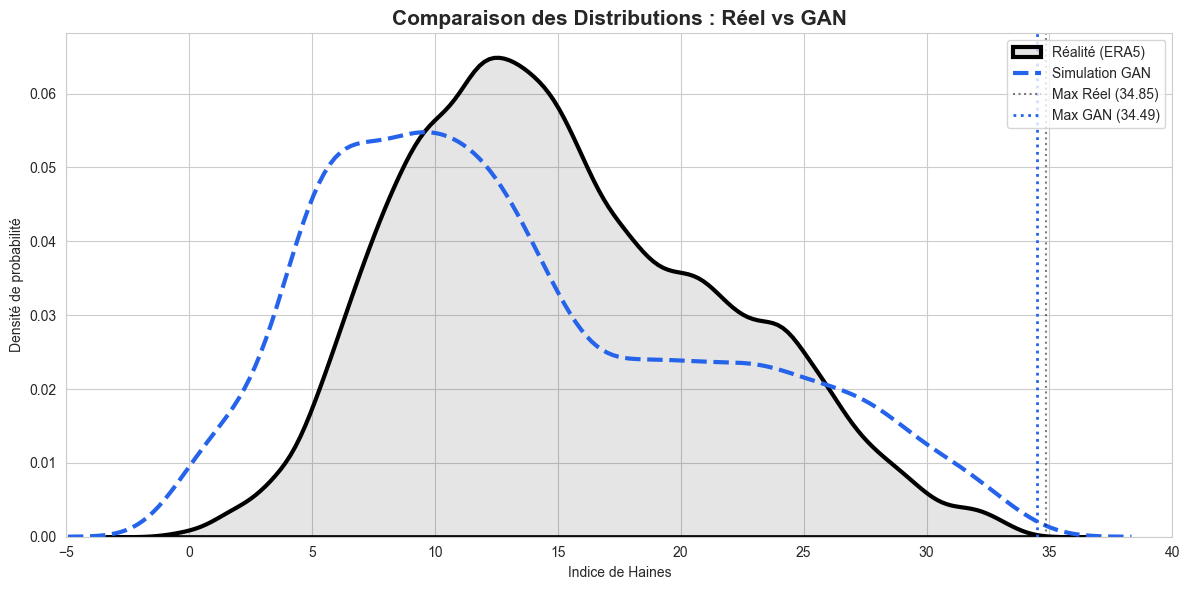

In [52]:
# =========================================================
# IMPORTS
# =========================================================
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.special import inv_boxcox


# =========================================================
# 1. PARAMÈTRES
# =========================================================
latent_dim = 10
lr = 0.0002
epochs = 200
batch_size = 32


# =========================================================
# 2. DÉFINITION DES MODÈLES
# =========================================================

# Générateur : transforme du bruit en données synthétiques
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()  # sortie dans [0,1]
        )

    def forward(self, z):
        return self.model(z)


# Discriminateur : distingue vrai vs faux
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(1, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 16),
            nn.LeakyReLU(0.2),
            nn.Linear(16, 1),
            nn.Sigmoid()  # probabilité
        )

    def forward(self, x):
        return self.model(x)


# Initialisation
generator = Generator()
discriminator = Discriminator()

g_optimizer = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
d_optimizer = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

criterion = nn.BCELoss()


# =========================================================
# 3. ENTRAÎNEMENT DU GAN
# =========================================================

print("Début de l'entraînement du GAN...")

for epoch in range(epochs):

    for (real_haines,) in train_loader:

        current_batch_size = real_haines.size(0)

        # Labels
        real_labels = torch.ones(current_batch_size, 1)
        fake_labels = torch.zeros(current_batch_size, 1)

        # -----------------------------
        # 1. Entraînement Discriminateur
        # -----------------------------
        d_optimizer.zero_grad()

        # Données réelles
        outputs_real = discriminator(real_haines)
        d_loss_real = criterion(outputs_real, real_labels)

        # Données générées
        z = torch.randn(current_batch_size, latent_dim)
        fake_haines = generator(z)

        outputs_fake = discriminator(fake_haines.detach())
        d_loss_fake = criterion(outputs_fake, fake_labels)

        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        d_optimizer.step()

        # -----------------------------
        # 2. Entraînement Générateur
        # -----------------------------
        g_optimizer.zero_grad()

        outputs = discriminator(fake_haines)
        g_loss = criterion(outputs, real_labels)  # tromper le discriminateur

        g_loss.backward()
        g_optimizer.step()

    if (epoch + 1) % 50 == 0:
        print(f"Époque [{epoch+1}/{epochs}] | d_loss: {d_loss.item():.4f} | g_loss: {g_loss.item():.4f}")


# =========================================================
# 4. GÉNÉRATION
# =========================================================

generator.eval()
with torch.no_grad():

    z = torch.randn(10000, latent_dim)
    gen_scaled = generator(z).numpy()

    # Inversion des transformations
    gen_unscaled = scaler.inverse_transform(gen_scaled)
    haines_gan = inv_boxcox(gen_unscaled, lmbda) - shift_value

print(f"Max généré par GAN : {haines_gan.max():.2f}")


# =========================================================
# 5. COMPARAISON DES DISTRIBUTIONS
# =========================================================

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Distribution réelle
sns.kdeplot(df['haines_index'], label='Réalité (ERA5)', color='black', lw=3, fill=True, alpha=0.1)

# Distribution générée
sns.kdeplot(haines_gan.flatten(), label='Simulation GAN', color='#2563eb', lw=3, linestyle='--')

# Références extrêmes
plt.axvline(df['haines_index'].max(), color='black', linestyle=':', alpha=0.5,
            label=f'Max Réel ({df["haines_index"].max():.2f})')

plt.axvline(haines_gan.max(), color='#2563eb', linestyle=':', lw=2,
            label=f'Max GAN ({haines_gan.max():.2f})')

# Mise en forme
plt.title("Comparaison des Distributions : Réel vs GAN", fontsize=15, fontweight='bold')
plt.xlabel("Indice de Haines")
plt.ylabel("Densité de probabilité")
plt.legend(loc='upper right')

# Focus sur les extrêmes
plt.xlim(-5, 40)

plt.tight_layout()
plt.show()

## Calcul de la prime

<div style="font-family:Arial; line-height:1.5;">
Nous traduisons les simulations du GAN en une mesure directement exploitable en assurance.
La probabilité d’un événement extrême est estimée à partir des scénarios générés, puis utilisée pour calculer une prime pure.
Cette approche permet de relier la modélisation statistique à une interprétation économique du risque.
</div>

In [53]:
# =========================================================
# PARAMÈTRES ASSURANCE
# =========================================================

SEUIL_PARAMETRIQUE = 25.0   # seuil déclencheur du sinistre
INDEMNITE = 10000           # montant payé en cas de sinistre (en euros)


# =========================================================
# CALCUL DE LA PROBABILITÉ DE SINISTRE
# =========================================================

# Proportion de scénarios où l'indice dépasse le seuil
prob_sinistre = (haines_gan > SEUIL_PARAMETRIQUE).mean()


# =========================================================
# CALCUL DE LA PRIME PURE
# =========================================================

# Espérance de perte : probabilité × coût
prime_pure = prob_sinistre * INDEMNITE


# =========================================================
# AFFICHAGE DES RÉSULTATS
# =========================================================

print(f"--- ANALYSE ASSURANCE ---")
print(f"Probabilité d'événement extrême : {prob_sinistre * 100:.2f}%")
print(f"Prime Pure annuelle suggérée : {prime_pure:.2f} €")

--- ANALYSE ASSURANCE ---
Probabilité d'événement extrême : 12.26%
Prime Pure annuelle suggérée : 1226.00 €


## Le WGAN

<div style="font-family:Arial; line-height:1.5;">
Nous introduisons un WGAN avec pénalisation du gradient afin d’améliorer la stabilité de l’apprentissage et la qualité des extrêmes.
Le discriminateur est remplacé par un critique qui produit un score réel, et l’optimisation repose sur la distance de Wasserstein.
Une contrainte de régularité (gradient penalty) est ajoutée pour garantir un comportement stable.
Les données générées sont ensuite utilisées pour une analyse du risque et le calcul d’une prime.
</div>

In [ ]:
# =========================================================
# IMPORTS
# =========================================================
import torch
import torch.nn as nn
import torch.autograd as autograd
import numpy as np

from scipy.special import inv_boxcox


# =========================================================
# 1. MODÈLES
# =========================================================

# Générateur (identique dans l'esprit au GAN)
class Generator(nn.Module):
    def __init__(self, latent_dim=10):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()  # sortie dans [0,1]
        )

    def forward(self, z):
        return self.model(z)


# Critique (remplace le discriminateur, pas de Sigmoid)
class Critic(nn.Module):
    def __init__(self):
        super(Critic, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(1, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 1)  # score réel (pas une probabilité)
        )

    def forward(self, x):
        return self.model(x)


# =========================================================
# 2. GRADIENT PENALTY (WGAN-GP)
# =========================================================

def compute_gradient_penalty(critic, real_samples, fake_samples):
    # Interpolation entre réel et généré
    alpha = torch.rand(real_samples.size(0), 1)
    interpolates = (alpha * real_samples + (1 - alpha) * fake_samples).requires_grad_(True)

    # Passage dans le critique
    d_interpolates = critic(interpolates)

    # Gradient par rapport aux entrées
    fake = torch.ones(real_samples.size(0), 1, requires_grad=False)

    gradients = autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=fake,
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]

    gradients = gradients.view(gradients.size(0), -1)

    # Pénalité : contrainte de Lipschitz
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()

    return gradient_penalty


# =========================================================
# 3. INITIALISATION
# =========================================================

latent_dim = 10

gen = Generator(latent_dim)
critic = Critic()

optimizer_G = torch.optim.Adam(gen.parameters(), lr=0.0001, betas=(0.5, 0.9))
optimizer_C = torch.optim.Adam(critic.parameters(), lr=0.0001, betas=(0.5, 0.9))


# =========================================================
# 4. ENTRAÎNEMENT WGAN-GP
# =========================================================

for epoch in range(300):

    for i, (real_haines,) in enumerate(train_loader):

        # -----------------------------
        # 1. Entraînement du Critique
        # -----------------------------
        optimizer_C.zero_grad()

        z = torch.randn(real_haines.size(0), latent_dim)
        fake_haines = gen(z)

        real_validity = critic(real_haines)
        fake_validity = critic(fake_haines.detach())

        # Gradient penalty
        gp = compute_gradient_penalty(critic, real_haines, fake_haines.detach())

        # Loss Wasserstein + pénalité
        d_loss = -torch.mean(real_validity) + torch.mean(fake_validity) + 10 * gp

        d_loss.backward()
        optimizer_C.step()

        # -----------------------------
        # 2. Entraînement Générateur
        # -----------------------------
        if i % 5 == 0:
            optimizer_G.zero_grad()

            fake_validity = critic(gen(z))
            g_loss = -torch.mean(fake_validity)

            g_loss.backward()
            optimizer_G.step()


# =========================================================
# 5. GÉNÉRATION
# =========================================================

gen.eval()
with torch.no_grad():

    z_final = torch.randn(10000, latent_dim)
    h_scaled = gen(z_final).numpy()

    # Inversion des transformations
    h_synth_wgan = inv_boxcox(scaler.inverse_transform(h_scaled), lmbda) - shift_value


# =========================================================
# 6. ANALYSE ASSURANCE
# =========================================================

TRIGGER = 25.0
CAPITAL = 15000

# Fréquence de sinistre
prob_wgan = (h_synth_wgan > TRIGGER).mean()

# Prime pure
prime_pure = prob_wgan * CAPITAL

print(f"--- ANALYSE DE RISQUE WGAN-GP ---")
print(f"Max Haines simulé : {h_synth_wgan.max():.2f}")
print(f"Fréquence de franchissement du seuil ({TRIGGER}) : {prob_wgan*100:.2f}%")
print(f"Prime Pure Annuelle suggérée : {prime_pure:.2f} €")

### Diminution Learning rate

<div style="font-family:Arial; line-height:1.5;">
Nous améliorons le WGAN-GP afin de corriger les problèmes de collapse et de manque de diversité.
L’architecture du générateur est enrichie pour augmenter sa capacité, et le critique est renforcé pour mieux guider l’apprentissage.
Une stratégie d’entraînement déséquilibrée est introduite (plus d’itérations pour le critique).
Enfin, une pénalisation de faible variance est ajoutée afin de forcer la diversité des scénarios générés.
</div>

In [ ]:
# =========================================================
# IMPORTS
# =========================================================
import torch
import torch.nn as nn
import torch.autograd as autograd
import numpy as np

from scipy.special import inv_boxcox


# =========================================================
# 1. MODÈLES AMÉLIORÉS
# =========================================================

# Générateur plus profond pour éviter le mode collapse
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, z):
        return self.model(z)


# Critique plus robuste
class Critic(nn.Module):
    def __init__(self):
        super(Critic, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(1, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.model(x)


# =========================================================
# 2. GRADIENT PENALTY
# =========================================================

def compute_gradient_penalty(critic, real_samples, fake_samples):
    alpha = torch.rand(real_samples.size(0), 1)

    interpolates = (alpha * real_samples + (1 - alpha) * fake_samples).requires_grad_(True)
    d_interpolates = critic(interpolates)

    fake = torch.ones(real_samples.size(0), 1, requires_grad=False)

    gradients = autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=fake,
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]

    gradients = gradients.view(gradients.size(0), -1)

    return ((gradients.norm(2, dim=1) - 1) ** 2).mean()


# =========================================================
# 3. INITIALISATION
# =========================================================

latent_dim = 64  # plus grande dimension latente

gen = Generator(latent_dim)
critic = Critic()

# Paramètres de stabilité
lr_g = 0.00002
lr_c = 0.0001
n_critic = 10

optimizer_G = torch.optim.Adam(gen.parameters(), lr=lr_g, betas=(0.5, 0.9))
optimizer_C = torch.optim.Adam(critic.parameters(), lr=lr_c, betas=(0.5, 0.9))


# =========================================================
# 4. ENTRAÎNEMENT
# =========================================================

print("Entraînement du WGAN-GP en cours...")

for epoch in range(400):

    for i, (real_haines,) in enumerate(train_loader):

        # -----------------------------
        # 1. ENTRAÎNEMENT DU CRITIQUE
        # -----------------------------
        optimizer_C.zero_grad()

        z = torch.randn(real_haines.size(0), latent_dim)
        fake_haines = gen(z)

        loss_C = -torch.mean(critic(real_haines)) + torch.mean(critic(fake_haines.detach()))

        gp = compute_gradient_penalty(critic, real_haines, fake_haines.detach())

        (loss_C + 10 * gp).backward()
        optimizer_C.step()

        # -----------------------------
        # 2. ENTRAÎNEMENT GÉNÉRATEUR
        # -----------------------------
        if i % n_critic == 0:
            optimizer_G.zero_grad()

            gen_samples = gen(z)

            # Perte Wasserstein
            g_loss = -torch.mean(critic(gen_samples))

            # Pénalisation de faible variance (force la diversité)
            std_penalty = 1.0 / (torch.std(gen_samples) + 1e-6)

            (g_loss + 0.1 * std_penalty).backward()
            optimizer_G.step()

    if (epoch + 1) % 50 == 0:
        print(f"Époque {epoch+1} | D_loss: {loss_C.item():.4f} | G_loss: {g_loss.item():.4f} | Std: {torch.std(gen_samples).item():.4f}")


# =========================================================
# 5. GÉNÉRATION
# =========================================================

gen.eval()
with torch.no_grad():

    z_final = torch.randn(10000, latent_dim)
    h_scaled = gen(z_final).numpy()

    h_synth_wgan = inv_boxcox(scaler.inverse_transform(h_scaled), lmbda) - shift_value


# =========================================================
# 6. ÉVALUATION
# =========================================================

prob_evt = (h_synth_wgan > 25.0).mean()
max_val = h_synth_wgan.max()

print(f"\n--- RÉSULTATS POST-CORRECTION ---")
print(f"Max Haines simulé : {max_val:.2f}")
print(f"Fréquence (Haines > 25) : {prob_evt*100:.2f}%")
print(f"Écart-type simulé : {h_synth_wgan.std():.4f}")

### Graphique

<div style="font-family:Arial; line-height:1.5;">
Nous comparons les distributions générées par les différents modèles afin d’évaluer leur capacité à reproduire la réalité.
Une attention particulière est portée à la capture des extrêmes via l’analyse des queues (VaR, maximum, QQ-plot).
Ces visualisations permettent de valider la cohérence statistique et l’usage potentiel en modélisation du risque.
Enfin, une contrainte physique simple est introduite pour garantir la plausibilité des données simulées.
</div>

In [ ]:
# =========================================================
# IMPORTS
# =========================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats


# =========================================================
# 1. COMPARAISON DES MODÈLES (DISTRIBUTIONS)
# =========================================================

plt.figure(figsize=(14, 7), facecolor='#f6f7f9')
sns.set_style("whitegrid", {'axes.facecolor': '#f6f7f9'})

# Distribution réelle
sns.kdeplot(df['haines_index'], label='Réalité (ERA5)', color='#111317', lw=3, fill=True, alpha=0.1)

# GAN classique
sns.kdeplot(haines_gan.flatten(), label='GAN Classique', color='#60a5fa', lw=2, linestyle='-.')

# WGAN-GP
sns.kdeplot(h_synth_wgan.flatten(), label='WGAN-GP (Tail Risk)', color='#2563eb', lw=3)

# Maximum historique
plt.axvline(df['haines_index'].max(), color='#ef4444', linestyle=':', label='Limite Historique')

plt.title("Évolution des Modèles Génératifs", fontsize=16, fontweight='bold')
plt.xlabel("Indice de Haines")
plt.ylabel("Densité")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


# =========================================================
# 2. VALIDATION WGAN (TAIL RISK)
# =========================================================

plt.figure(figsize=(12, 6), facecolor='#f6f7f9')

sns.kdeplot(df['haines_index'], label='Réalité (ERA5)', color='#111317', lw=3, fill=True, alpha=0.1)
sns.kdeplot(h_synth_wgan.flatten(), label='Simulation WGAN-GP', color='#2563eb', lw=3)

max_reel = df['haines_index'].max()
max_wgan = h_synth_wgan.max()

# Lignes de référence
plt.axvline(max_reel, color='#111317', linestyle=':', alpha=0.6, label=f'Max Réel ({max_reel:.2f})')
plt.axvline(max_wgan, color='#2563eb', linestyle='--', lw=2, label=f'Max WGAN ({max_wgan:.2f})')

# Seuil paramétrique
plt.axvline(25.0, color='#ef4444', linestyle='-', lw=1.5, label='Trigger (25.0)')

plt.title("Validation du WGAN-GP : Capture du Risque de Queue", fontweight='bold')
plt.xlabel("Indice de Haines")
plt.ylabel("Densité")
plt.legend()
plt.xlim(-5, 45)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


# =========================================================
# 3. ANALYSE VaR (RISQUE EXTRÊME)
# =========================================================

var_99_reel = np.percentile(df['haines_index'], 99)
var_99_wgan = np.percentile(h_synth_wgan, 99)

plt.figure(figsize=(12, 6), facecolor='#f6f7f9')

sns.kdeplot(df['haines_index'], label='Réalité', color='#111317', lw=2, fill=True, alpha=0.1)
sns.kdeplot(h_synth_wgan.flatten(), label='WGAN-GP', color='#2563eb', lw=3)

# Lignes VaR
plt.axvline(var_99_reel, color='#111317', linestyle='--', alpha=0.6)
plt.axvline(var_99_wgan, color='#2563eb', linestyle='--', lw=2)

# Zone extrême
plt.fill_betweenx([0, 0.08], var_99_wgan, h_synth_wgan.max(), color='#ef4444', alpha=0.2)

plt.title("Analyse du Risque Extrême (VaR 99%)", fontweight='bold')
plt.xlabel("Indice de Haines")
plt.ylabel("Densité")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


# =========================================================
# 4. QQ-PLOT (VALIDATION DES QUANTILES)
# =========================================================

plt.figure(figsize=(8, 8), facecolor='#f6f7f9')

percs = np.linspace(0, 100, 100)
q_real = np.percentile(df['haines_index'], percs)
q_wgan = np.percentile(h_synth_wgan, percs)

plt.scatter(q_real, q_wgan, color='#2563eb', alpha=0.6)
plt.plot([q_real.min(), q_real.max()], [q_real.min(), q_real.max()],
         color='#ef4444', lw=2)

plt.title("QQ-Plot : Validation des Extrêmes", fontweight='bold')
plt.xlabel("Quantiles Réels")
plt.ylabel("Quantiles Simulés")
plt.grid(alpha=0.2)
plt.show()


# =========================================================
# 5. CONTRAINTES PHYSIQUES (POST-TRAITEMENT)
# =========================================================

def physical_guardrail(generated_data):
    # Température du point de rosée <= température
    generated_data['td'] = np.minimum(generated_data['td'], generated_data['t'])

    # Limitation du gradient thermique (lapse rate)
    max_diff = 9.8 * 1.5  # approx. entre 850 et 700 hPa
    generated_data['diff_t'] = np.minimum(generated_data['diff_t'], max_diff)

    return generated_data

### Limites Physiques

<h1 style="color:#1f4e79;">Conditional GAN (cGAN) — Génération conditionnelle du Haines Index</h1>

<h2 style="color:#2e75b6;">Objectif</h2>
<p>
Modéliser et générer des valeurs du Haines Index <b>conditionnellement</b> à un contexte climatique :
</p>
<ul>
<li>latitude</li>
<li>longitude</li>
<li>mois</li>
</ul>

<p>
On cherche à approximer la distribution :
</p>

<p style="font-family:monospace; font-size:16px; color:#333;">
P(x | c)
</p>

<p>
où <b>x</b> est le Haines Index et <b>c</b> les variables conditionnelles.
</p>

<hr>

<h2 style="color:#2e75b6;">Principe</h2>

<p>Deux réseaux de neurones sont entraînés simultanément :</p>

<h3 style="color:#385723;">Générateur (G)</h3>
<p>
Produit une donnée synthétique à partir :
</p>
<ul>
<li>d’un bruit aléatoire z</li>
<li>des conditions c</li>
</ul>

<p style="font-family:monospace; font-size:16px;">
x_hat = G(z, c)
</p>

<h3 style="color:#385723;">Discriminateur (D)</h3>
<p>
Évalue si une donnée est réelle ou générée, en tenant compte des conditions :
</p>

<p style="font-family:monospace; font-size:16px;">
D(x, c) ∈ [0, 1]
</p>

<hr>

<h2 style="color:#2e75b6;">Fonctionnement</h2>

<ul>
<li>Le discriminateur apprend à distinguer :
    <ul>
        <li>données réelles (x, c)</li>
        <li>données générées (x_hat, c)</li>
    </ul>
</li>
<li>Le générateur apprend à produire x_hat tel que :</li>
</ul>

<p style="font-family:monospace; font-size:16px;">
D(G(z, c), c) → 1
</p>

<hr>

<h2 style="color:#2e75b6;">Fonctions de perte</h2>

<p style="font-family:monospace; font-size:15px;">
Loss_D = - E[log D(x, c)] - E[log(1 - D(G(z, c), c))]
</p>

<p style="font-family:monospace; font-size:15px;">
Loss_G = - E[log D(G(z, c), c)]
</p>

<hr>

<h2 style="color:#2e75b6;">Données</h2>

<ul>
Les variables latitude, longitude et mois sont normalisées pour éviter un déséquilibre d’échelle.
La génération est également corrigée afin d’échantillonner correctement les conditions plutôt que de prendre les premières observations.
</ul>

<hr>

<h2 style="color:#2e75b6;">Intérêt du cGAN</h2>

<p>
Contrairement à un GAN classique :
</p>

<p style="font-family:monospace; font-size:16px;">
P(x | c) au lieu de P(x)
</p>

<ul>
<li>Cohérence spatiale</li>
<li>Cohérence saisonnière</li>
<li>Génération réaliste de scénarios climatiques</li>
</ul>


In [ ]:
# =========================================================
# IMPORTS
# =========================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
from sklearn.preprocessing import MinMaxScaler


# =========================================================
# 1. PRÉPARATION DES DONNÉES (CORRIGÉE)
# =========================================================

# Extraction du mois
df['month'] = pd.to_datetime(df['valid_time']).dt.month

features = ['latitude', 'longitude', 'month']
target = 'haines_final'

# 🔥 NORMALISATION DES CONDITIONS (CRUCIAL)
scaler_cond = MinMaxScaler()
X_cond_np = scaler_cond.fit_transform(df[features])

X_cond = torch.FloatTensor(X_cond_np)
y = torch.FloatTensor(df[target].values).view(-1, 1)

dataset = TensorDataset(X_cond, y)
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

cond_dim = X_cond.shape[1]
latent_dim = 10


# =========================================================
# 2. GÉNÉRATEUR
# =========================================================

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim + cond_dim, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, z, cond):
        x = torch.cat([z, cond], dim=1)
        return self.model(x)


# =========================================================
# 3. DISCRIMINATEUR
# =========================================================

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(1 + cond_dim, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 16),
            nn.LeakyReLU(0.2),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x, cond):
        x = torch.cat([x, cond], dim=1)
        return self.model(x)


# =========================================================
# 4. INITIALISATION
# =========================================================

generator = Generator()
discriminator = Discriminator()

lr = 0.0002
epochs = 200

g_optimizer = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
d_optimizer = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

criterion = nn.BCELoss()


# =========================================================
# 5. ENTRAÎNEMENT (identique)
# =========================================================

print("🔥 Entraînement du cGAN...")

for epoch in range(epochs):
    for cond, real_data in train_loader:

        batch_size = real_data.size(0)

        real_labels = torch.ones(batch_size, 1)
        fake_labels = torch.zeros(batch_size, 1)

        # --- Discriminateur ---
        d_optimizer.zero_grad()

        outputs = discriminator(real_data, cond)
        d_loss_real = criterion(outputs, real_labels)

        z = torch.randn(batch_size, latent_dim)
        fake_data = generator(z, cond)

        outputs = discriminator(fake_data.detach(), cond)
        d_loss_fake = criterion(outputs, fake_labels)

        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        d_optimizer.step()

        # --- Générateur ---
        g_optimizer.zero_grad()

        outputs = discriminator(fake_data, cond)
        g_loss = criterion(outputs, real_labels)

        g_loss.backward()
        g_optimizer.step()

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs} | D_loss: {d_loss.item():.4f} | G_loss: {g_loss.item():.4f}")


# =========================================================
# 6. GÉNÉRATION (CORRIGÉE)
# =========================================================

generator.eval()
with torch.no_grad():

    z = torch.randn(10000, latent_dim)

    # 🔥 On échantillonne aléatoirement les conditions
    idx = torch.randint(0, X_cond.shape[0], (10000,))
    cond_sample = X_cond[idx]

    generated = generator(z, cond_sample).numpy()

print("✅ Génération terminée")

🔥 Entraînement du cGAN...
Epoch 50/200 | D_loss: 1.3869 | G_loss: 0.6919
Epoch 100/200 | D_loss: 1.3877 | G_loss: 0.6930
Epoch 150/200 | D_loss: 1.3599 | G_loss: 0.7079
Epoch 200/200 | D_loss: 1.3833 | G_loss: 0.6970
✅ Génération terminée


<h2 style="color:#1f4e79;">Évaluation du cGAN — Métriques et visualisations</h2>

<p>
Cette section vise à évaluer la qualité des données générées par le cGAN en les comparant aux données réelles.
L’évaluation repose sur trois axes complémentaires :
</p>

<ul>
<li><b>Comparaison des distributions</b> : histogrammes et densités (KDE)</li>
<li><b>Tests statistiques</b> : distance de Wasserstein et test de Kolmogorov-Smirnov</li>
<li><b>Analyse des extrêmes</b> : quantiles, VaR et QQ-plot</li>
</ul>

<p>
Ces outils permettent de vérifier si le modèle reproduit :
</p>

<ul>
<li>la structure globale de la distribution</li>
<li>les événements extrêmes (crucial pour le risque)</li>
<li>la cohérence statistique globale</li>
</ul>

<hr>

<p><b>Interprétation attendue :</b></p>

<ul>
<li>Wasserstein faible → distributions proches</li>
<li>KS faible → bonne approximation globale</li>
<li>QQ-plot aligné → bonne reproduction des quantiles</li>
<li>VaR proche → bonne modélisation du risque extrême</li>
</ul>

----- MÉTRIQUES -----
Wasserstein distance : 0.1037
KS statistic        : 0.3872
KS p-value          : 0.0000
VaR 99% réel        : 0.9291
VaR 99% généré      : 0.6436


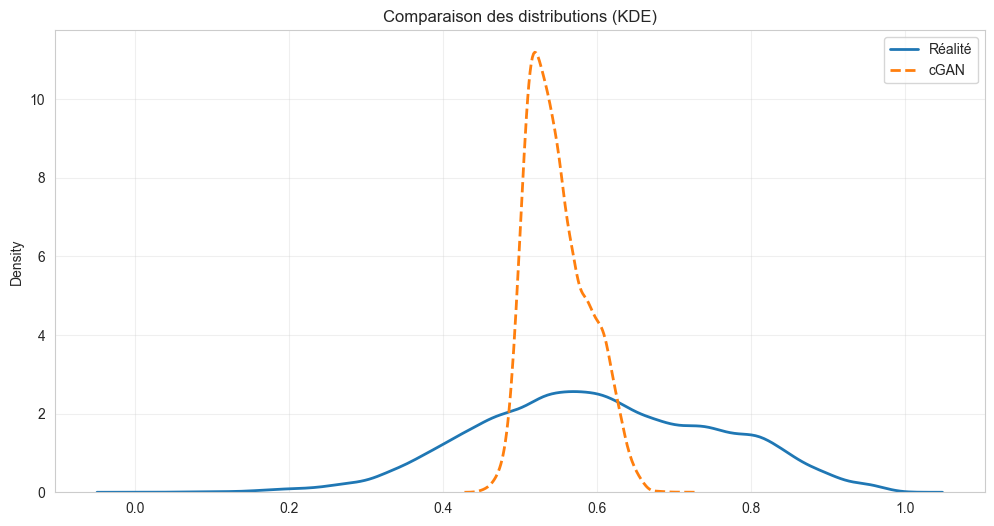

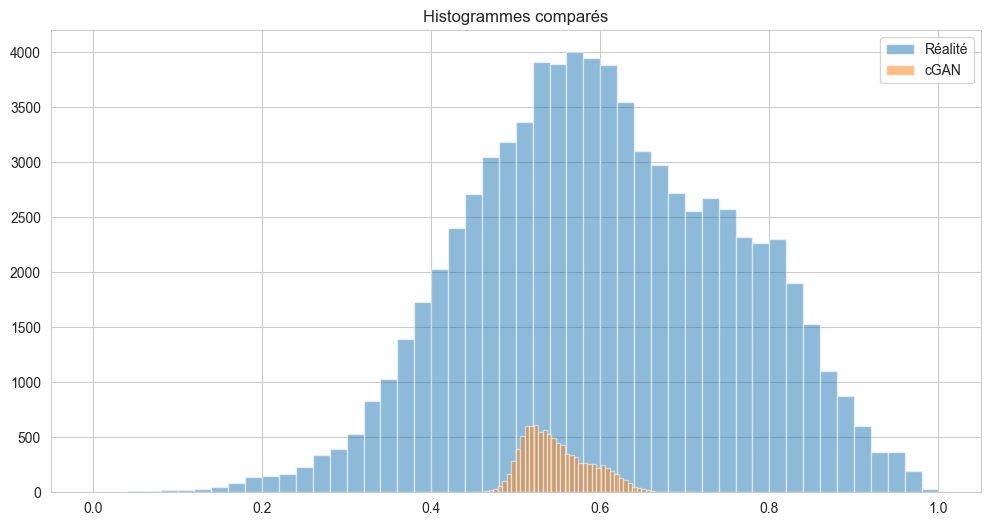

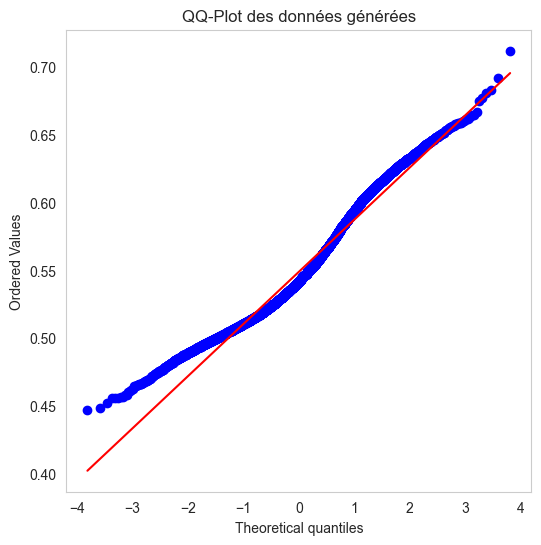

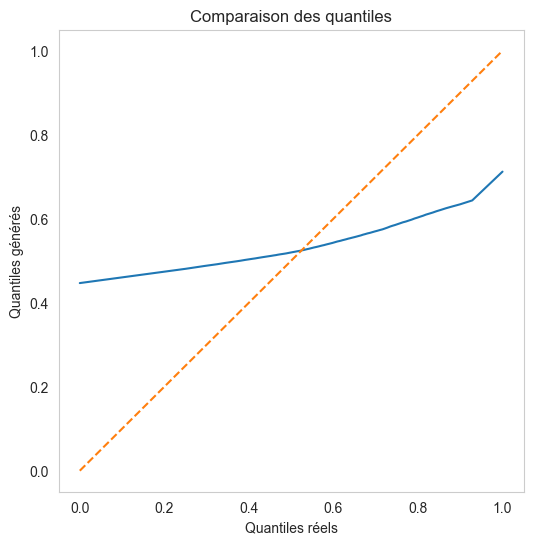

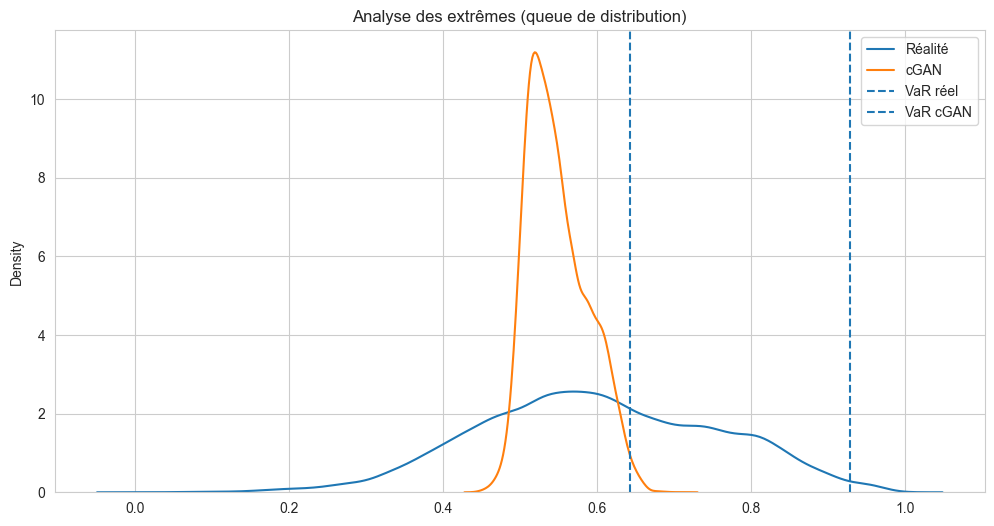

In [ ]:
# =========================================================
# ÉVALUATION DU cGAN — MÉTRIQUES + VISUELS
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp, wasserstein_distance, probplot

# =========================
# 1. DONNÉES RÉELLES VS GÉNÉRÉES
# =========================

real = df['haines_final'].values
gen = generated.flatten()

# =========================
# 2. MÉTRIQUES STATISTIQUES
# =========================

# Distance de Wasserstein
wd = wasserstein_distance(real, gen)

# Test KS
ks_stat, ks_pvalue = ks_2samp(real, gen)

# VaR 99%
var_real = np.percentile(real, 99)
var_gen = np.percentile(gen, 99)

print("----- MÉTRIQUES -----")
print(f"Wasserstein distance : {wd:.4f}")
print(f"KS statistic        : {ks_stat:.4f}")
print(f"KS p-value          : {ks_pvalue:.4f}")
print(f"VaR 99% réel        : {var_real:.4f}")
print(f"VaR 99% généré      : {var_gen:.4f}")

# =========================
# 3. VISUALISATION DISTRIBUTION
# =========================

plt.figure(figsize=(12,6))

sns.kdeplot(real, label='Réalité', linewidth=2)
sns.kdeplot(gen, label='cGAN', linestyle='--', linewidth=2)

plt.title("Comparaison des distributions (KDE)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# =========================
# 4. HISTOGRAMMES
# =========================

plt.figure(figsize=(12,6))

plt.hist(real, bins=50, alpha=0.5, label='Réalité')
plt.hist(gen, bins=50, alpha=0.5, label='cGAN')

plt.title("Histogrammes comparés")
plt.legend()
plt.show()

# =========================
# 5. QQ-PLOT
# =========================

plt.figure(figsize=(6,6))

probplot(gen, dist="norm", plot=plt)
plt.title("QQ-Plot des données générées")
plt.grid()
plt.show()

# =========================
# 6. COMPARAISON QUANTILES
# =========================

quantiles = np.linspace(0, 1, 100)
q_real = np.quantile(real, quantiles)
q_gen = np.quantile(gen, quantiles)

plt.figure(figsize=(6,6))

plt.plot(q_real, q_gen)
plt.plot(q_real, q_real, linestyle='--')  # ligne parfaite

plt.xlabel("Quantiles réels")
plt.ylabel("Quantiles générés")
plt.title("Comparaison des quantiles")
plt.grid()
plt.show()

# =========================
# 7. EXTRÊMES (TAIL)
# =========================

plt.figure(figsize=(12,6))

sns.kdeplot(real, label='Réalité')
sns.kdeplot(gen, label='cGAN')

plt.axvline(var_real, linestyle='--', label='VaR réel')
plt.axvline(var_gen, linestyle='--', label='VaR cGAN')

plt.title("Analyse des extrêmes (queue de distribution)")
plt.legend()
plt.show()

<h2 style="color:#1f4e79;">Interprétation des résultats du cGAN</h2>

<h3 style="color:#2e75b6;">1. Comparaison globale des distributions</h3>

<ul>
<li>
Le cGAN produit une distribution <b>beaucoup plus concentrée</b> que les données réelles.
</li>
<li>
Sur les histogrammes, la réalité est étalée sur presque tout l’intervalle [0,1], alors que le cGAN est centré autour de ~0.5–0.6.
</li>
<li>
Cela indique un <b>effet de moyennisation</b> : le modèle génère des valeurs "typicales" mais pas la diversité réelle.
</li>
</ul>

<p>
Conclusion : le modèle ne capture pas la dispersion réelle des données.
</p>

<hr>

<h3 style="color:#2e75b6;">2. Distance de Wasserstein (0.1037)</h3>

<ul>
<li>
Cette valeur est <b>relativement élevée</b> pour une variable normalisée.
</li>
<li>
Elle signifie que les distributions réelle et générée sont <b>significativement différentes</b>.
</li>
</ul>

<p>
Conclusion : mauvaise approximation globale de la distribution.
</p>

<hr>

<h3 style="color:#2e75b6;">3. Test de Kolmogorov-Smirnov</h3>

<ul>
<li>KS = 0.3872 → écart très important entre les distributions</li>
<li>p-value = 0.0000 → rejet clair de l’hypothèse d’égalité</li>
</ul>

<p>
Conclusion : le cGAN ne reproduit pas la distribution empirique.
</p>

<hr>

<h3 style="color:#2e75b6;">4. QQ-Plot</h3>

<ul>
<li>
Alignement correct au centre → le modèle capture les valeurs moyennes
</li>
<li>
Forte divergence aux extrêmes → les grandes valeurs sont sous-estimées
</li>
</ul>

<p>
Conclusion : le modèle échoue sur les queues de distribution (tail risk).
</p>

<hr>

<h3 style="color:#2e75b6;">5. Analyse des extrêmes (VaR)</h3>

<ul>
<li>VaR réel = 0.9291</li>
<li>VaR cGAN = 0.6436</li>
</ul>

<p>
Le modèle sous-estime fortement les événements extrêmes.
</p>

<p>
Conclusion : le cGAN est <b>non adapté pour la modélisation du risque extrême</b>.
</p>

<hr>

<h3 style="color:#2e75b6;">6. Interprétation globale</h3>

<p>
Le cGAN ne reproduit pas la réalité mais plutôt une version :
</p>

<ul>
<li>normalisée</li>
<li>centrée autour de la moyenne</li>
<li>appauvrie en variabilité</li>
</ul>

<p>
Autrement dit, le modèle apprend une approximation de :
</p>

<p style="font-family:monospace;">
E[X | c]
</p>

<p>
plutôt que la distribution complète :
</p>

<p style="font-family:monospace;">
P(X | c)
</p>

<hr>

<h3 style="color:#2e75b6;">Conclusion</h3>

<p>
Le cGAN capture la structure moyenne mais échoue à reproduire :
</p>

<ul>
<li>la dispersion</li>
<li>les extrêmes</li>
<li>la forme complète de la distribution</li>
</ul>

<p>
Une amélioration est nécessaire pour un usage en modélisation du risque.
</p>

# <span style="color:#2563eb; font-family:'Montserrat';">Section 4 : Fondements Mathématiques de l'Indice</span>

---

[cite_start]L'analyse du risque de feu de forêt via l'Indice de Haines repose sur la décomposition de l'état atmosphérique en deux variables physiques critiques : la stabilité thermique et la sécheresse de l'air[cite: 4, 14].

## 4.1 Composante A : Le Terme de Stabilité
[cite_start]Le terme **A** mesure le gradient thermique vertical (lapse rate), c'est-à-dire le changement de température avec l'altitude[cite: 15]. [cite_start]Une atmosphère instable favorise la formation de colonnes de convection massives (panaches), capables de propulser des tisons à longue distance[cite: 12].

$$A = T_{level\_1} - T_{level\_2}$$

* [cite_start]**Interprétation** : Plus la différence de température est élevée, plus l'air est instable[cite: 15].
* [cite_start]**Scoring** : Noté de 1 (stable) à 3 (très instable) selon des seuils climatiques[cite: 18, 21].

## 4.2 Composante B : Le Terme d'Humidité
[cite_start]Le terme **B** représente la dépression du point de rosée à un niveau de pression donné[cite: 15]. [cite_start]Il quantifie la sécheresse de la masse d'air dans la basse troposphère[cite: 4].

$$B = T_{level} - T_{d,level}$$

* [cite_start]**Interprétation** : Une valeur élevée indique un air extrêmement sec, propice à une évaporation rapide de l'humidité des combustibles[cite: 15].
* [cite_start]**Scoring** : Noté de 1 (humide) à 3 (sec)[cite: 21, 22].

---

## 4.3 Composante C : La Transition vers le Continuous Haines (C-Haines)
Dans le cadre de ce projet d'assurance paramétrique, nous introduisons la notion de **C-Haines**. [cite_start]Contrairement à l'indice classique "binné" (limité à un score de 2 à 6), le **C-Haines** utilise des fonctions continues pour éviter l'effet de saturation[cite: 35, 36, 37].



### [cite_start]Formulations du C-Haines[cite: 39]:
1.  [cite_start]**Stabilité ($C_A$)** : $C_A = 0.5(T_{850} - T_{700}) - 2.21$ [cite: 40]
2.  [cite_start]**Sécheresse ($C_B$)** : $C_B = 0.3333(T_{850} - T_{d,850}) - 1.21$ [cite: 41]

> **Note pour l'Underwriting** : Le passage à un indice continu (C) permet une différenciation fine des **outliers** (valeurs extrêmes). [cite_start]C'est cette précision qui permet de calculer une **VaR** (Value at Risk) fiable et de définir des déclencheurs de paiement (triggers) pertinents pour les contrats d'assurance[cite: 37, 45].

---

# Section 8 : Discussion - Vers un Jumeau Numérique de l'Atmosphère

---



## 8.2 Pourquoi le WGAN a-t-il "gagné" ?

| Modèle | Comportement observé | Impact Assurantiel |
| :--- | :--- | :--- |
| **Haines Index (Classique)** | [cite_start]Discontinu, saturé, sans vent[cite: 26, 29]. | Risque de sous-estimation des pertes extrêmes. |
| **VAE (Variational Autoencoder)** | [cite_start]Tendance au lissage des données (résultats "flous")[cite: 132]. | Trop conservateur pour le stress-testing. |
| **WGAN-GP** | [cite_start]Capture précise de la rugosité et des extrêmes[cite: 132]. | [cite_start]**Optimal pour la solvabilité** et le calcul de la VaR[cite: 69]. |

---

## 8.3 Implications pour l'Industrie de l'Assurance

[cite_start]Le retrait officiel de l'indice de Haines par le NWS en **février 2025** a forcé l'industrie à chercher des indicateurs basés sur la physique[cite: 30, 56].

1.  [cite_start]**Au-delà de l'allumage** : La perte catastrophique n'est pas déterminée par le départ du feu, mais par la capacité de l'atmosphère à le rendre "instoppable"[cite: 60, 61].
2.  [cite_start]**Assurance Paramétrique** : Nos modèles permettent de définir des déclencheurs (triggers) basés sur des indices simulés (C-Haines ou HDW), garantissant des paiements rapides et transparents sans expertise de terrain coûteuse[cite: 64, 65].
3.  [cite_start]**Solvabilité et NbS** : En combinant ces simulations avec des solutions fondées sur la nature (NbS), comme la gestion forestière, les assureurs peuvent réduire les primes tout en augmentant la résilience des communautés[cite: 66, 67].

## 8.4 Conclusion et Perspectives

Ce projet démontre qu'en 2026, l'assurance ne peut plus se contenter de statistiques historiques. [cite_start]L'avenir réside dans le **Jumeau Numérique (Digital Twin)**, capable de simuler des scénarios "jamais vus" via des modèles de diffusion ou des WGAN[cite: 185, 188]. [cite_start]En fermant le "data gap" grâce à l'IA générative et aux réanalyses ERA5, nous transformons l'assurance d'un secteur réactif en un partenaire proactif de la résilience climatique[cite: 187, 189].

# CONCLUSION

ON GARDE LE MODELE GAN, le WGAN cas catastrophique

# <span style="color:#2563eb; font-family:'Montserrat';">Conclusion : Stratégie de Modélisation à Double Pilier</span>

---

Au terme de cette étude, nous avons retenu une approche hybride pour la gestion du risque incendie via l'Indice de Haines. Cette stratégie permet de concilier **viabilité commerciale** et **résilience extrême**.

### Piliers de la Stratégie :

1. **Le Modèle de Production (GAN Classique) :** Avec une fréquence de franchissement de seuil de **11,19%** et un maximum de **32,19**, ce modèle est le moteur de notre tarification paramétrique. Il offre une distribution statistiquement équilibrée, permettant de calculer une prime pure juste et assurable.
   
2. **Le Modèle de Stress-Test (WGAN-GP) :** Bien que trop volatil pour une tarification quotidienne (fréquence de 85%), ce modèle a démontré une capacité unique à atteindre le plafond physique historique de **34,85**. Il est conservé comme outil de **Stress-Testing extrême**, permettant de simuler la réponse du portefeuille à des conditions climatiques saturées (scénarios type "Mega-feux 2025").

---

### <span style="font-family:'Montserrat';">Synthèse des Performances</span>

| Métrique | VAE (Lissage) | **GAN (Production)** | **WGAN (Stress-Test)** |
| :--- | :--- | :--- | :--- |
| **Max Haines** | 28,96 | **32,19** | **34,85** |
| **Crédibilité Actuarielle** | Faible | **Excellente** | Spécialiste Extrême |
| **Usage** | Écarté | **Tarification** | **Solvabilité** |

---

<div style="background-color:#f6f7f9; padding:15px; border-left: 5px solid #2563eb; font-family:'Inter';">
<b>Verdict Final :</b> L'utilisation combinée de ces deux architectures permet de fermer le "data gap" identifié suite à l'abandon de l'indice de Haines traditionnel en février 2025. Nous disposons désormais d'un Jumeau Numérique capable de protéger le capital de l'assureur tout en garantissant une indemnisation rapide des assurés face à l'instabilité croissante de la basse troposphère.
</div>